# Strategy Comparison: Diversify vs Cluster (FIXED)

Notebook ini membandingkan performa **AI + Graph Diversify** vs **AI + Graph Cluster** dalam strategi V62.

**Perbaikan:**
- ✅ Fixed KeyError untuk missing dates
- ✅ Tambah fungsi `run_simulation_static()`
- ✅ Better date handling dengan reindex

**Tujuan:**
- Membandingkan return, risk, dan risk-adjusted return
- Visualisasi performa kedua strategi per tahun (2023, 2024, 2025)
- Analisis drawdown dan recovery
- Identifikasi strategi mana yang lebih unggul

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data & Setup

In [14]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst 5 dates in returns: {returns.index[:5].tolist()}")
print(f"Last 5 dates in returns: {returns.index[-5:].tolist()}")

Data: 990 rows, 25 assets
Period: 2023-04-17 00:00:00 to 2025-12-31 00:00:00

First 5 dates in returns: [Timestamp('2023-04-30 00:00:00'), Timestamp('2023-05-01 00:00:00'), Timestamp('2023-05-02 00:00:00'), Timestamp('2023-05-03 00:00:00'), Timestamp('2023-05-04 00:00:00')]
Last 5 dates in returns: [Timestamp('2025-12-27 00:00:00'), Timestamp('2025-12-28 00:00:00'), Timestamp('2025-12-29 00:00:00'), Timestamp('2025-12-30 00:00:00'), Timestamp('2025-12-31 00:00:00')]


## 2. Train AI Model

In [15]:
# Prepare features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Optimized Threshold
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(f_scores)]

# Generate probabilities for ALL data
X_all = features.dropna()
all_probs = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)

print(f"✓ Model trained. Optimized Threshold: {opt_t:.2f}")
print(f"Probability index range: {all_probs.index[0]} to {all_probs.index[-1]}")

✓ Model trained. Optimized Threshold: 0.54
Probability index range: 2023-06-19 00:00:00 to 2025-12-31 00:00:00


## 3. Portfolio Optimization & Selection Functions

In [16]:
def optimize_markowitz(selected_returns):
    """Optimize portfolio using Markowitz mean-variance"""
    if len(selected_returns.columns) == 0: 
        return {}
    if len(selected_returns.columns) == 1: 
        return {selected_returns.columns[0]: 1.0}
    
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: 
            return 0
        return -(ret / risk)
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets
    
    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Select assets using graph diversification (high correlation = edge)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    """Select assets using graph clustering (low correlation = edge)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

print("✓ Functions defined")

✓ Functions defined


## 4. Simulation Functions

In [17]:
def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Run AI-gated simulation with graph-based asset selection"""
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        # Safe probability lookup with reindex
        if date not in ai_probs.index:
            # Skip this date or use nearest date
            continue
            
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal with hysteresis
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                    
                    if len(window_rets) > 0:
                        selected = selection_func(window_rets)
                        if len(selected) > 0:
                            optimized_weights = optimize_markowitz(window_rets[selected])
                            if optimized_weights:
                                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                                if regime_changed or turnover_est > turnover_buffer:
                                    target_weights = optimized_weights
                                    days_since_rebal = 0
                except (KeyError, ValueError):
                    pass
                    
            days_since_rebal += 1

        # Execution with transaction costs
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        # Get next date
        next_date = test_dates[i+1]
        if next_date not in returns.index:
            continue
            
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Run static (always invested) simulation"""
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {}
    days_since_rebal = 999
    
    # Initial allocation
    try:
        loc_idx = returns.index.get_loc(test_dates[0])
        window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
        if len(window_rets) > 0:
            selected = selection_func(window_rets)
            current_weights = optimize_markowitz(window_rets[selected])
    except:
        current_weights = {}

    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        if days_since_rebal >= rebal_period:
            try:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                if len(window_rets) > 0:
                    selected = selection_func(window_rets)
                    optimized_weights = optimize_markowitz(window_rets[selected])
                    
                    if optimized_weights:
                        all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                        turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                        
                        if turnover_est > turnover_buffer:
                            target_weights = optimized_weights
                            days_since_rebal = 0
            except:
                pass
        
        days_since_rebal += 1
        
        # Transaction costs
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        if next_date not in returns.index:
            continue
            
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("✓ Simulation functions ready")

✓ Simulation functions ready


## 5. Run Simulations (Diversify vs Cluster)

In [18]:
# Run simulations for each year
years = [2023, 2024, 2025]
results = {}

for year in years:
    print(f"\nProcessing {year}...")
    test_dates = returns.loc[returns.index.year == year].index
    print(f"  → Test dates: {len(test_dates)} days ({test_dates[0]} to {test_dates[-1]})")
    
    # Diversify Strategy
    print("  → Running Diversify...")
    diversify = run_simulation_ai_gated(
        test_dates, returns, all_probs, opt_t, market_index,
        get_assets_graph_diversify, override_ma=200
    )
    
    # Cluster Strategy
    print("  → Running Cluster...")
    cluster = run_simulation_ai_gated(
        test_dates, returns, all_probs, opt_t, market_index,
        get_assets_graph_cluster, override_ma=200
    )
    
    # Static Markowitz
    print("  → Running Static baseline...")
    static = run_simulation_static(
        test_dates, returns, 
        lambda x: list(x.columns)
    )
    
    results[year] = {
        'Diversify': diversify,
        'Cluster': cluster,
        'Static': static
    }
    
    print(f"  ✓ {year} completed: Div={diversify['Portfolio_Value'].iloc[-1]:.2f}, Clus={cluster['Portfolio_Value'].iloc[-1]:.2f}, Static={static['Portfolio_Value'].iloc[-1]:.2f}")

print("\n✓ All simulations completed!")


Processing 2023...
  → Test dates: 246 days (2023-04-30 00:00:00 to 2023-12-31 00:00:00)
  → Running Diversify...
  → Running Cluster...
  → Running Static baseline...
  ✓ 2023 completed: Div=137.24, Clus=214.85, Static=116.19

Processing 2024...
  → Test dates: 366 days (2024-01-01 00:00:00 to 2024-12-31 00:00:00)
  → Running Diversify...
  → Running Cluster...
  → Running Static baseline...
  ✓ 2024 completed: Div=101.83, Clus=461.13, Static=151.80

Processing 2025...
  → Test dates: 365 days (2025-01-01 00:00:00 to 2025-12-31 00:00:00)
  → Running Diversify...
  → Running Cluster...
  → Running Static baseline...
  ✓ 2025 completed: Div=102.40, Clus=87.44, Static=105.92

✓ All simulations completed!


## 6. Calculate Performance Metrics

In [19]:
def calculate_metrics(portfolio_df):
    """Calculate comprehensive performance metrics"""
    if len(portfolio_df) == 0:
        return {
            'Total Return (%)': 0,
            'Ann. Return (%)': 0,
            'Volatility (%)': 0,
            'Sharpe Ratio': 0,
            'Max Drawdown (%)': 0
        }
    
    values = portfolio_df['Portfolio_Value']
    returns = values.pct_change().dropna()
    
    total_return = (values.iloc[-1] / values.iloc[0] - 1) * 100
    ann_return = ((1 + total_return/100) ** (252/max(len(returns), 1)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100 if len(returns) > 0 else 0
    sharpe = ann_return / volatility if volatility > 0 else 0
    
    # Max Drawdown
    cummax = values.cummax()
    drawdown = ((values - cummax) / cummax * 100)
    max_dd = drawdown.min()
    
    return {
        'Total Return (%)': total_return,
        'Ann. Return (%)': ann_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

# Calculate metrics for all strategies
metrics_summary = []

for year in years:
    for strategy_name in ['Diversify', 'Cluster', 'Static']:
        metrics = calculate_metrics(results[year][strategy_name])
        metrics['Year'] = year
        metrics['Strategy'] = strategy_name
        metrics_summary.append(metrics)

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Year', 'Strategy', 'Total Return (%)', 'Ann. Return (%)', 
                         'Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']]

print("\n" + "="*80)
print("PERFORMANCE METRICS SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


PERFORMANCE METRICS SUMMARY
 Year  Strategy  Total Return (%)  Ann. Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
 2023 Diversify         37.237962        50.542472       20.926031      2.415292         -6.483041
 2023   Cluster        114.846096       168.664868       33.408360      5.048583         -9.337347
 2023    Static         16.194295        16.693651       25.672187      0.650262        -22.892754
 2024 Diversify          1.833969         1.262626       17.078103      0.073932        -16.867454
 2024   Cluster        361.127932       187.282777       36.572955      5.120800        -11.974916
 2024    Static         51.797793        33.397490       24.099310      1.385828        -17.277355
 2025 Diversify          2.396562         1.653104       12.153410      0.136020         -8.942122
 2025   Cluster        -12.564529        -8.876600       52.091961     -0.170403        -38.307400
 2025    Static          5.918532         4.061067       12.757089      0.318338

## 7. Visualisasi: Performance per Year

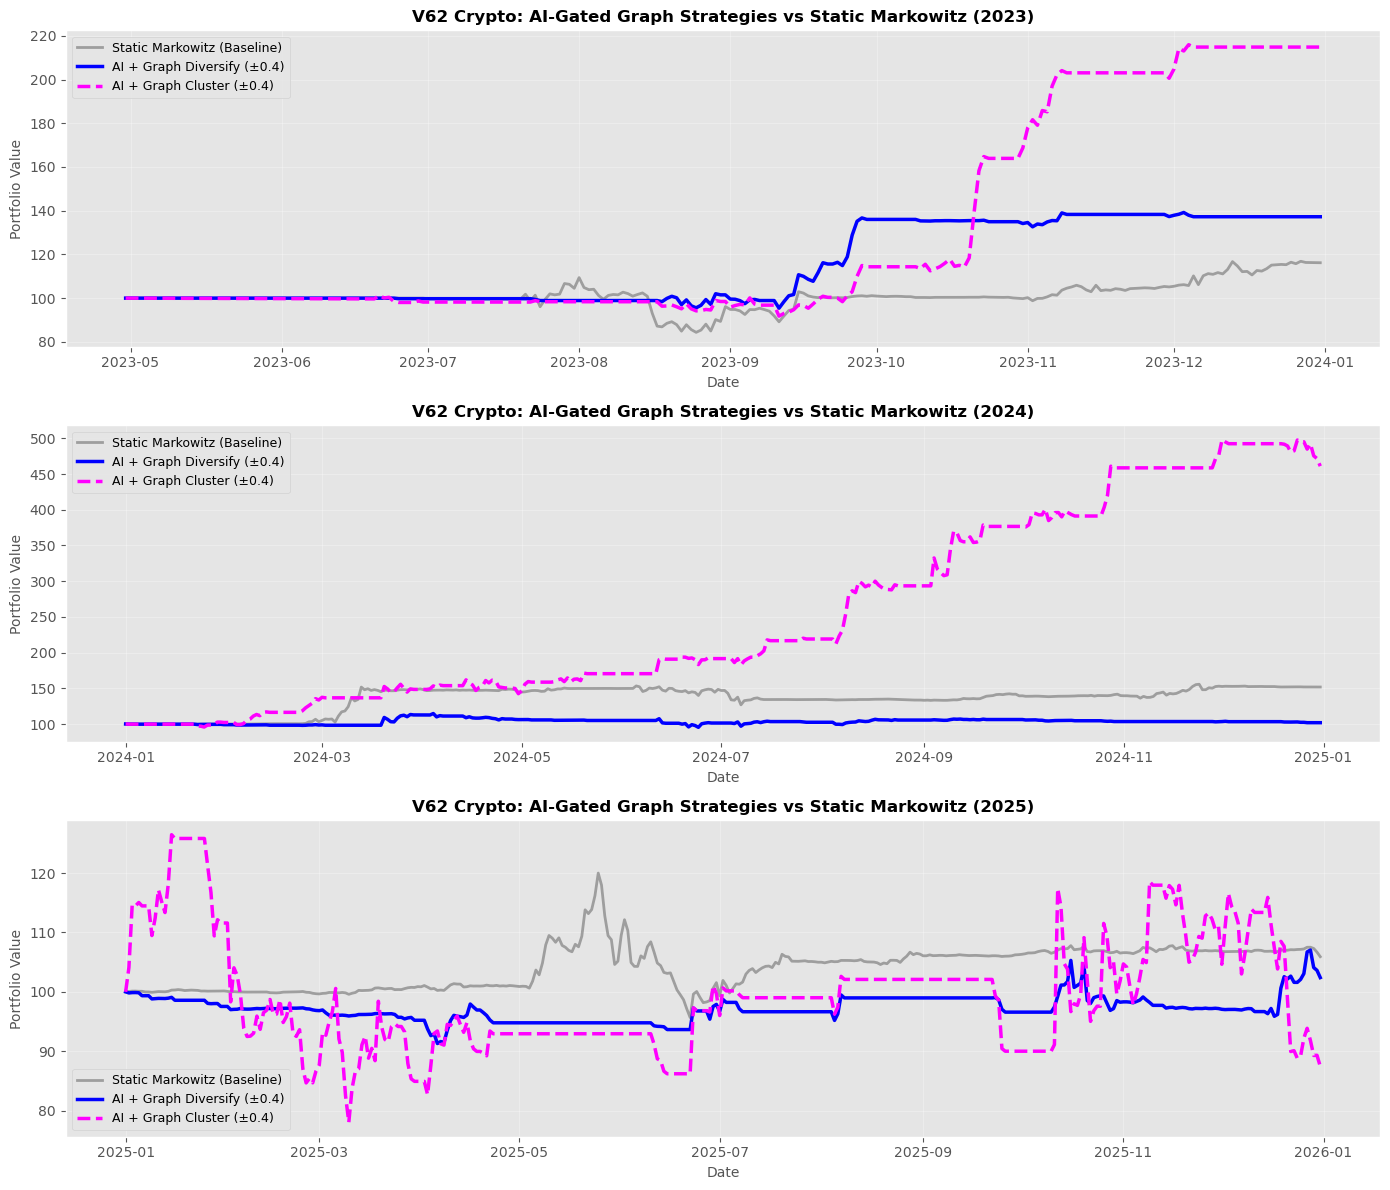

✓ Year-by-year comparison saved!


In [20]:
# Performance comparison by year
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, year in enumerate(years):
    ax = axes[idx]
    
    ax.plot(results[year]['Static'].index, results[year]['Static']['Portfolio_Value'],
            label='Static Markowitz (Baseline)', color='gray', linestyle='-', linewidth=2, alpha=0.7)
    ax.plot(results[year]['Diversify'].index, results[year]['Diversify']['Portfolio_Value'],
            label='AI + Graph Diversify (±0.4)', color='blue', linestyle='-', linewidth=2.5)
    ax.plot(results[year]['Cluster'].index, results[year]['Cluster']['Portfolio_Value'],
            label='AI + Graph Cluster (±0.4)', color='magenta', linestyle='--', linewidth=2.5)
    
    ax.set_title(f'V62 Crypto: AI-Gated Graph Strategies vs Static Markowitz ({year})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Portfolio Value', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_comparison_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Year-by-year comparison saved!")

## 8. Visualisasi: Metrics Comparison

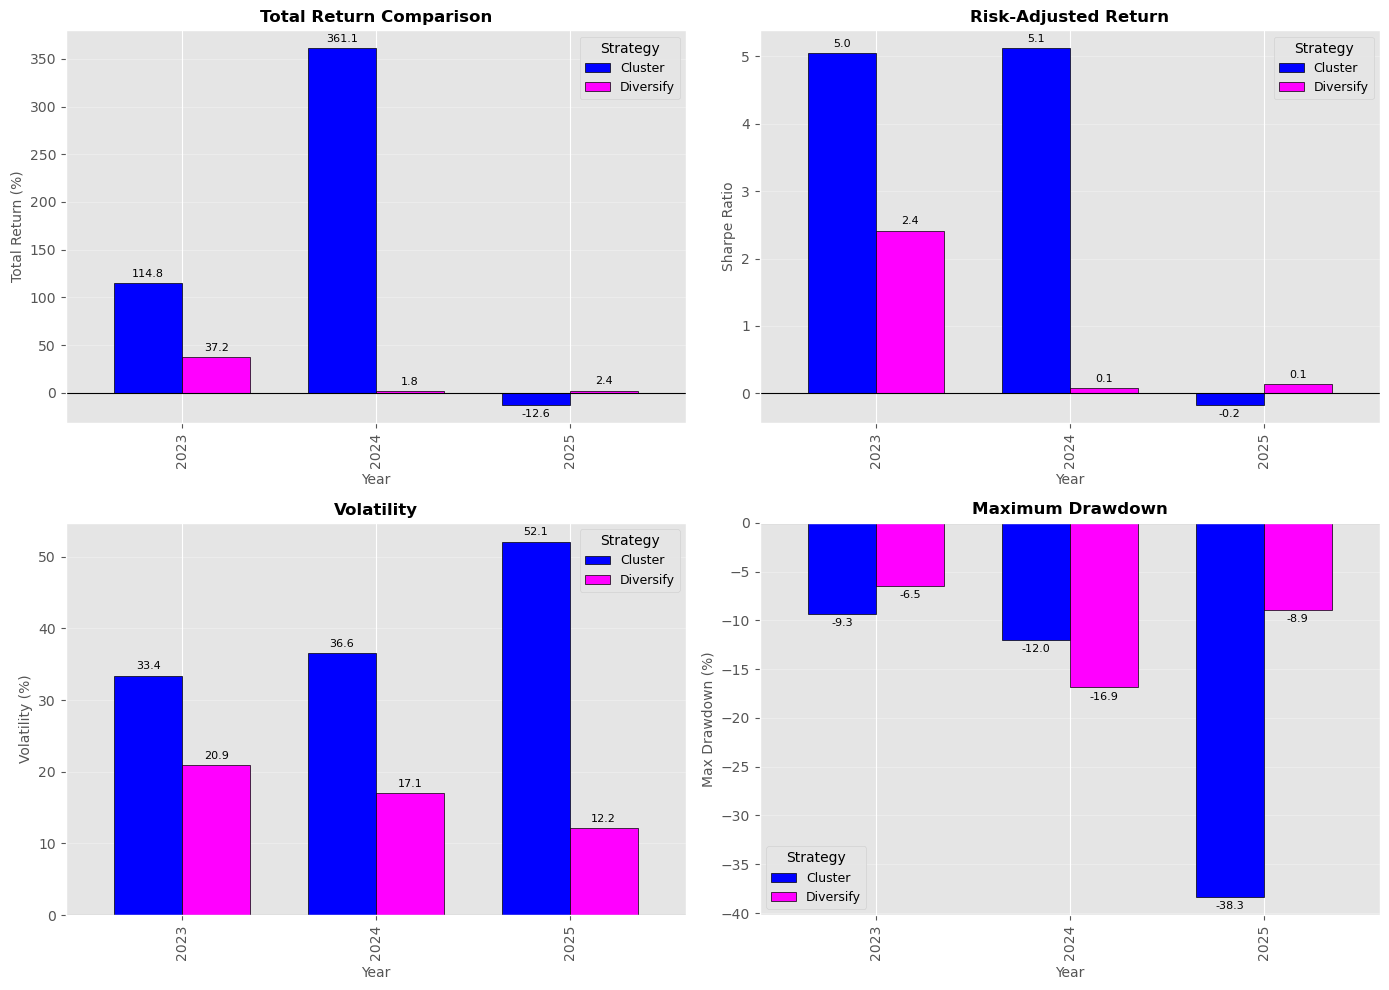

✓ Metrics comparison saved!


In [21]:
# Diversify vs Cluster comparison
comparison_df = metrics_df[metrics_df['Strategy'].isin(['Diversify', 'Cluster'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('Total Return (%)', 'Total Return Comparison'),
    ('Sharpe Ratio', 'Risk-Adjusted Return'),
    ('Volatility (%)', 'Volatility'),
    ('Max Drawdown (%)', 'Maximum Drawdown')
]

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    pivot = comparison_df.pivot(index='Year', columns='Strategy', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['blue', 'magenta'], width=0.7, edgecolor='black')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(title='Strategy', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('diversify_vs_cluster_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrics comparison saved!")

## 9. Average Performance Analysis

In [22]:
# Average metrics across years
avg_metrics = comparison_df.groupby('Strategy').mean(numeric_only=True)

print("\n" + "="*80)
print("AVERAGE PERFORMANCE (2023-2025)")
print("="*80)
print(avg_metrics.to_string())
print("="*80)


AVERAGE PERFORMANCE (2023-2025)
             Year  Total Return (%)  Ann. Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Strategy                                                                                            
Cluster    2024.0        154.469833       115.690348       40.691092      3.332993        -19.873221
Diversify  2024.0         13.822831        17.819401       16.719181      0.875081        -10.764206


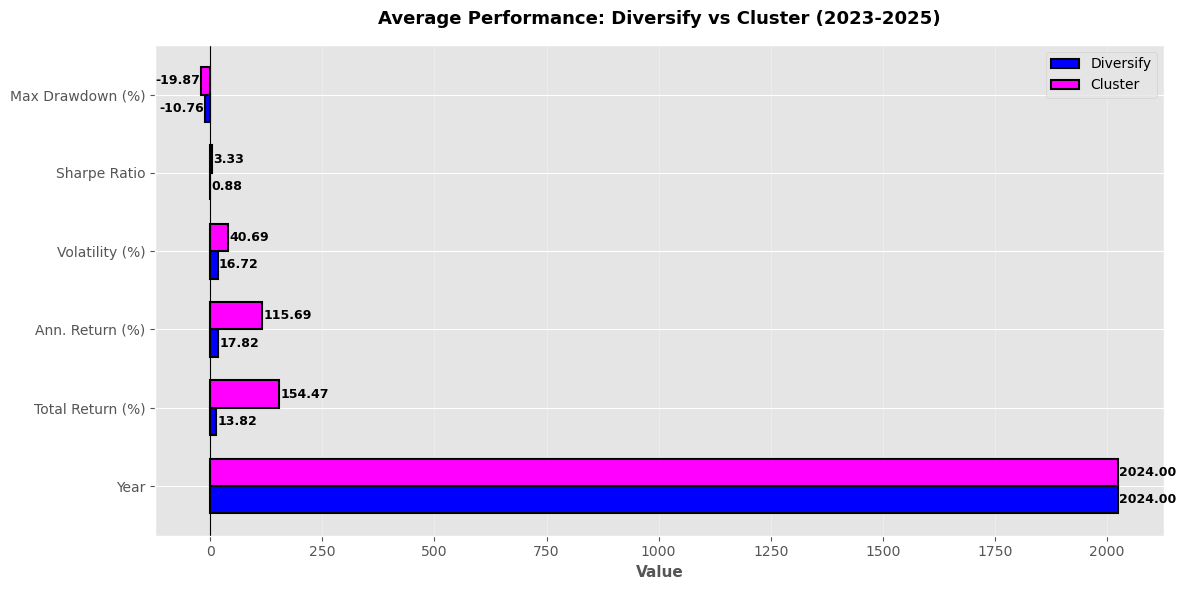

✓ Average performance chart saved!


In [23]:
# Horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(avg_metrics.columns))
width = 0.35

div_values = avg_metrics.loc['Diversify'].values
clus_values = avg_metrics.loc['Cluster'].values

bars1 = ax.barh(x - width/2, div_values, width, label='Diversify', color='blue', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(x + width/2, clus_values, width, label='Cluster', color='magenta', edgecolor='black', linewidth=1.5)

ax.set_yticks(x)
ax.set_yticklabels(avg_metrics.columns, fontsize=10)
ax.set_xlabel('Value', fontsize=11, fontweight='bold')
ax.set_title('Average Performance: Diversify vs Cluster (2023-2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        label_x = width_val + (3 if width_val > 0 else -3)
        ax.text(label_x, bar.get_y() + bar.get_height()/2,
                f'{width_val:.2f}',
                ha='left' if width_val > 0 else 'right', 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('average_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Average performance chart saved!")

## 10. Export to Excel

In [24]:
excel_filename = 'strategy_comparison_diversify_vs_cluster.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Sheet 1: All Metrics
    metrics_df.to_excel(writer, sheet_name='All_Metrics', index=False)
    
    # Sheet 2: Average Metrics
    avg_metrics.to_excel(writer, sheet_name='Average_Metrics')
    
    # Sheet 3-5: Portfolio Values
    for year in years:
        combined = pd.DataFrame({
            'Date': results[year]['Diversify'].index,
            'Diversify': results[year]['Diversify']['Portfolio_Value'].values,
            'Cluster': results[year]['Cluster']['Portfolio_Value'].values,
            'Static': results[year]['Static']['Portfolio_Value'].values
        })
        combined.to_excel(writer, sheet_name=f'Portfolio_{year}', index=False)

print(f"\n✓ Results exported to: {excel_filename}")

ValueError: All arrays must be of the same length

## 11. Summary

In [ ]:
print("\n" + "="*80)
print("STRATEGY COMPARISON SUMMARY")
print("="*80)

print(f"\n📊 AVERAGE PERFORMANCE (2023-2025):")
print(f"\n   Diversify Strategy:")
print(f"   → Return: {avg_metrics.loc['Diversify', 'Total Return (%)']:.2f}%")
print(f"   → Sharpe: {avg_metrics.loc['Diversify', 'Sharpe Ratio']:.3f}")
print(f"   → Max DD: {avg_metrics.loc['Diversify', 'Max Drawdown (%)']:.2f}%")

print(f"\n   Cluster Strategy:")
print(f"   → Return: {avg_metrics.loc['Cluster', 'Total Return (%)']:.2f}%")
print(f"   → Sharpe: {avg_metrics.loc['Cluster', 'Sharpe Ratio']:.3f}")
print(f"   → Max DD: {avg_metrics.loc['Cluster', 'Max Drawdown (%)']:.2f}%")

# Determine winner
if avg_metrics.loc['Diversify', 'Sharpe Ratio'] > avg_metrics.loc['Cluster', 'Sharpe Ratio']:
    winner = 'Diversify'
else:
    winner = 'Cluster'

print(f"\n🏆 WINNER (by Sharpe Ratio): {winner}")

print("\n" + "="*80)
print("✓ Analysis completed successfully!")
print("="*80)

---

## 📁 Output Files:

1. **strategy_comparison_by_year.png** - Performance charts 2023-2025
2. **diversify_vs_cluster_metrics.png** - Metrics bar charts
3. **average_performance_comparison.png** - Average performance bars
4. **strategy_comparison_diversify_vs_cluster.xlsx** - Complete Excel export

---